In [3]:
import os

os.environ['KAGGLE_USERNAME'] = "Koonany"
os.environ['KAGGLE_KEY'] = "KGAT_88166d3831f8bbea41de257f6e5e32dd"

!mkdir -p ~/.kaggle
!kaggle datasets download -d datasnaek/youtube-new
!unzip -q youtube-new.zip -d youtube_data
print("¡Descarga y descompresión completadas con éxito en 'youtube_data'!")

Dataset URL: https://www.kaggle.com/datasets/datasnaek/youtube-new
License(s): CC0-1.0
100% 201M/201M [00:01<00:00, 133MB/s]

¡Descarga y descompresión completadas con éxito en 'youtube_data'!


In [4]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]
df_us = pd.read_csv('youtube_data/USvideos.csv')

with open('youtube_data/US_category_id.json', 'r') as f:
    categories_data = json.load(f)

category_mapping = {}
for category in categories_data['items']:
    category_mapping[int(category['id'])] = category['snippet']['title']

df_us['category_name'] = df_us['category_id'].map(category_mapping)

print(df_us.info())
df_us.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40949 entries, 0 to 40948
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   video_id                40949 non-null  object
 1   trending_date           40949 non-null  object
 2   title                   40949 non-null  object
 3   channel_title           40949 non-null  object
 4   category_id             40949 non-null  int64 
 5   publish_time            40949 non-null  object
 6   tags                    40949 non-null  object
 7   views                   40949 non-null  int64 
 8   likes                   40949 non-null  int64 
 9   dislikes                40949 non-null  int64 
 10  comment_count           40949 non-null  int64 
 11  thumbnail_link          40949 non-null  object
 12  comments_disabled       40949 non-null  bool  
 13  ratings_disabled        40949 non-null  bool  
 14  video_error_or_removed  40949 non-null  bool  
 15  de

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,category_name
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...,People & Blogs
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John...",Entertainment
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...,Comedy


In [5]:
df_us['trending_date'] = pd.to_datetime(df_us['trending_date'], format='%y.%d.%m')
df_us['publish_time'] = pd.to_datetime(df_us['publish_time'], format='%Y-%m-%dT%H:%M:%S.%fZ', errors='coerce')
df_us['publish_date'] = df_us['publish_time'].dt.date
df_us['publish_date'] = pd.to_datetime(df_us['publish_date'])
df_us['days_to_trend'] = (df_us['trending_date'] - df_us['publish_date']).dt.days
df_us[['publish_date', 'trending_date', 'days_to_trend']].head()

,publish_date,trending_date,days_to_trend
0,2017-11-13,2017-11-14,1
1,2017-11-13,2017-11-14,1
2,2017-11-12,2017-11-14,2
3,2017-11-13,2017-11-14,1
4,2017-11-12,2017-11-14,2


In [6]:
ts_data = df_us.groupby('trending_date')[['views', 'likes', 'dislikes', 'comment_count']].sum().reset_index()
ts_data.set_index('trending_date', inplace=True)
ts_data = ts_data.asfreq('D', method='ffill')

print(f"Rango de fechas procesado: desde {ts_data.index.min()} hasta {ts_data.index.max()}")
ts_data.head()

Rango de fechas procesado: desde 2017-11-14 00:00:00 hasta 2018-06-14 00:00:00


,views,likes,dislikes,comment_count
trending_date,,,,
2017-11-14,185435246,7637635,270876,691402
2017-11-15,212445216,7601148,313577,709009
2017-11-16,227365391,7886807,338755,735962
2017-11-17,193541711,7143580,341176,814596
2017-11-18,196846875,8393717,322349,901370


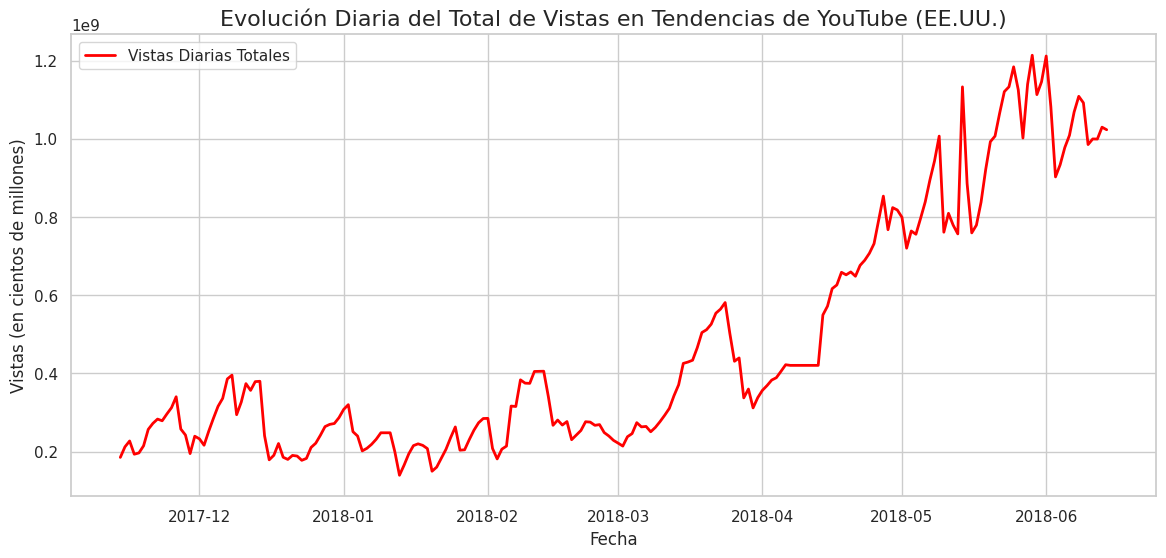

In [7]:
plt.figure(figsize=(14, 6))
plt.plot(ts_data.index, ts_data['views'], color='red', linewidth=2, label='Vistas Diarias Totales')
plt.title('Evolución Diaria del Total de Vistas en Tendencias de YouTube (EE.UU.)', fontsize=16)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Vistas (en cientos de millones)', fontsize=12)
plt.legend()
plt.show()

Fase 2: Exploración de los datos

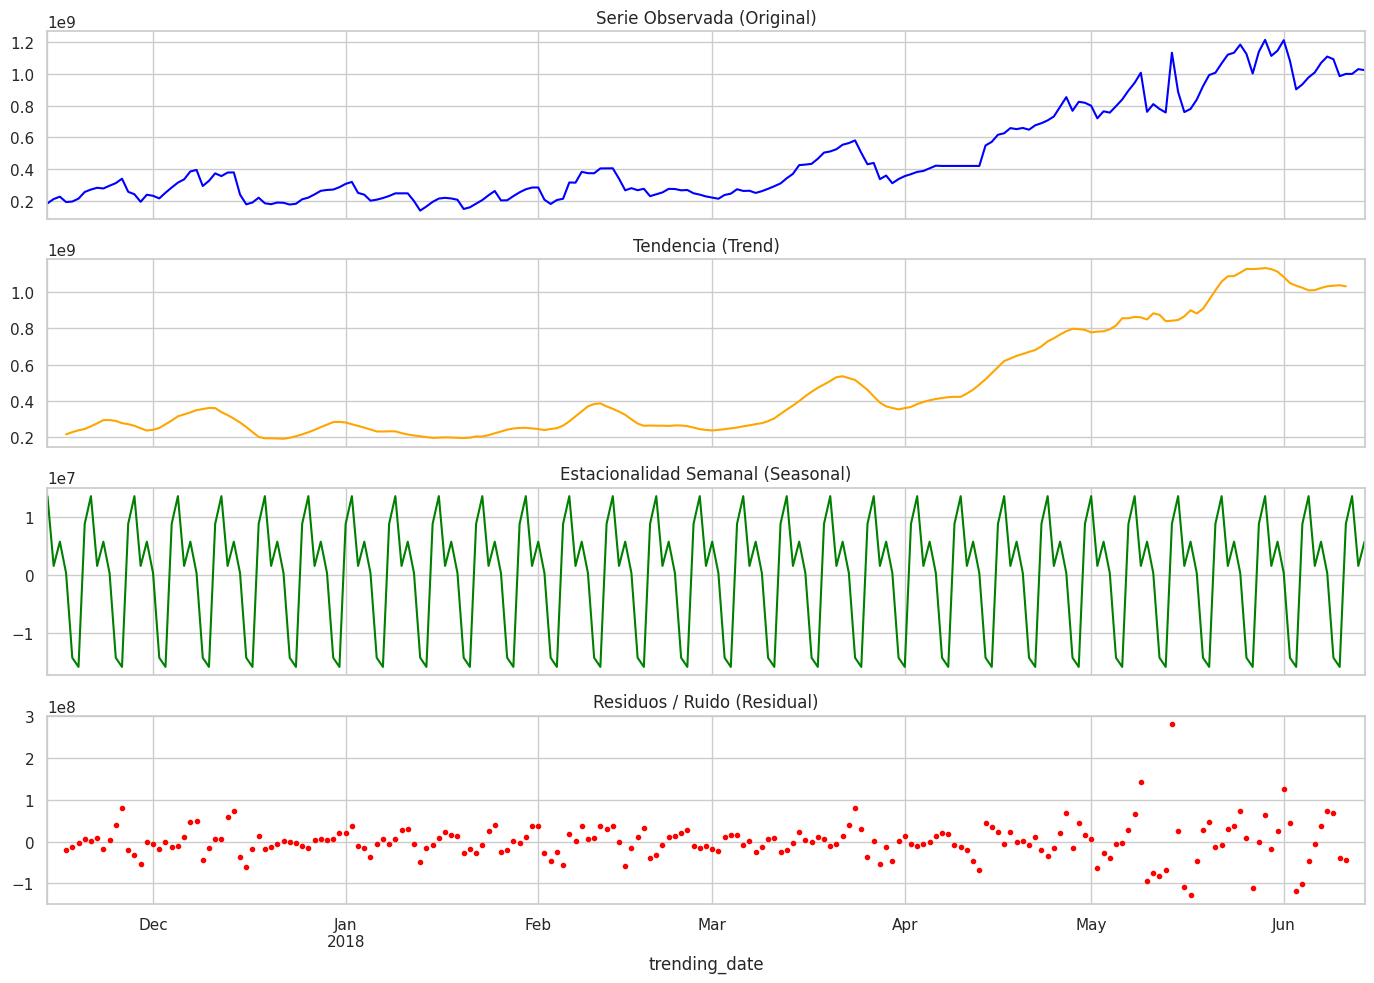

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose
descomposicion = seasonal_decompose(ts_data['views'], model='additive', period=7)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

descomposicion.observed.plot(ax=ax1, color='blue')
ax1.set_title('Serie Observada (Original)')
descomposicion.trend.plot(ax=ax2, color='orange')
ax2.set_title('Tendencia (Trend)')
descomposicion.seasonal.plot(ax=ax3, color='green')
ax3.set_title('Estacionalidad Semanal (Seasonal)')
descomposicion.resid.plot(ax=ax4, color='red', style='.')
ax4.set_title('Residuos / Ruido (Residual)')

plt.tight_layout()
plt.show()

/tmp/ipykernel_3713/789208239.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_analisis, x='dia_semana', y='views', order=orden_dias, palette='pastel')


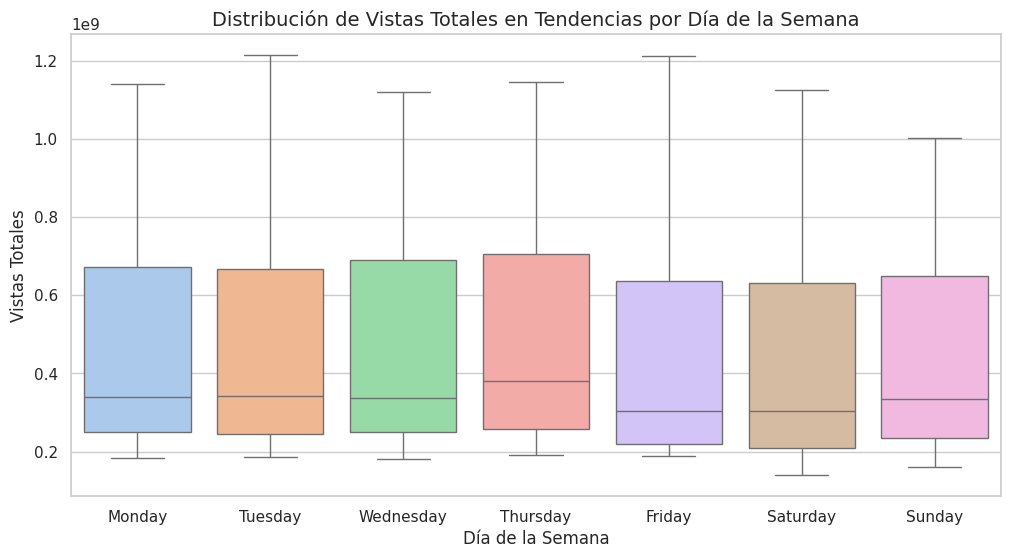

In [9]:
df_analisis = ts_data.copy()
df_analisis['dia_semana'] = df_analisis.index.day_name()

orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_analisis, x='dia_semana', y='views', order=orden_dias, palette='pastel')
plt.title('Distribución de Vistas Totales en Tendencias por Día de la Semana', fontsize=14)
plt.xlabel('Día de la Semana')
plt.ylabel('Vistas Totales')
plt.show()

In [12]:
from statsmodels.tsa.stattools import adfuller

def verificar_estacionariedad(serie):
    resultado = adfuller(serie.dropna())
    print('Prueba de Dickey-Fuller Aumentada')
    print(f'Estadístico ADF: {resultado[0]:.4f}')
    print(f'p-valor: {resultado[1]:.4f}')
    print('Valores Críticos:')
    for llave, valor in resultado[4].items():
        print(f'   {llave}: {valor:.4f}')

    # Interpretación estándar
    if resultado[1] <= 0.05:
        print("\n=> Conclusión: El p-valor es menor a 0.05. RECHAZAMOS la hipótesis nula. La serie ES ESTACIONARIA.")
    else:
        print("\n=> Conclusión: El p-valor es mayor a 0.05. NO rechazamos la hipótesis nula. La serie NO ES ESTACIONARIA (necesita diferenciación).")

verificar_estacionariedad(ts_data['views'])

Prueba de Dickey-Fuller Aumentada
Estadístico ADF: -0.1950
p-valor: 0.9391
Valores Críticos:
   1%: -3.4622
   5%: -2.8755
   10%: -2.5742

=> Conclusión: El p-valor es mayor a 0.05. NO rechazamos la hipótesis nula. La serie NO ES ESTACIONARIA (necesita diferenciación).


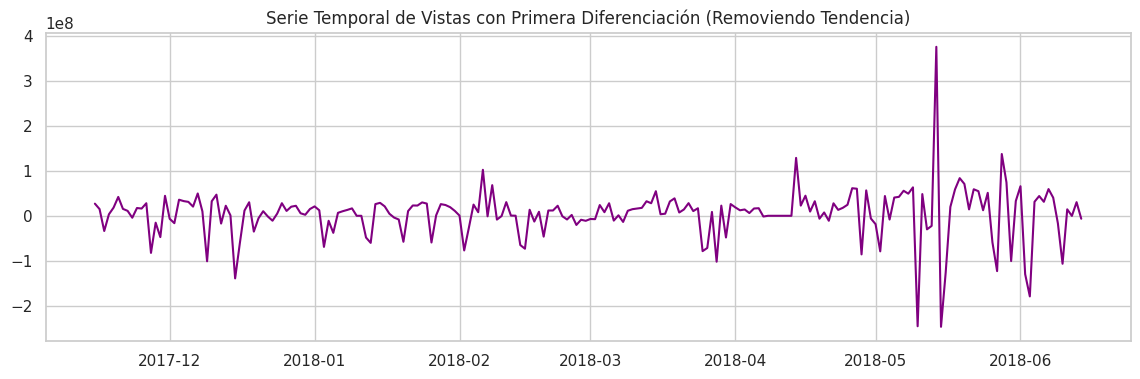

Prueba de Dickey-Fuller Aumentada
Estadístico ADF: -9.3668
p-valor: 0.0000
Valores Críticos:
   1%: -3.4622
   5%: -2.8755
   10%: -2.5742

=> Conclusión: El p-valor es menor a 0.05. RECHAZAMOS la hipótesis nula. La serie ES ESTACIONARIA.


In [13]:
ts_data_diff = ts_data['views'].diff().dropna()

plt.figure(figsize=(14, 4))
plt.plot(ts_data_diff, color='purple')
plt.title('Serie Temporal de Vistas con Primera Diferenciación (Removiendo Tendencia)')
plt.show()

verificar_estacionariedad(ts_data_diff)

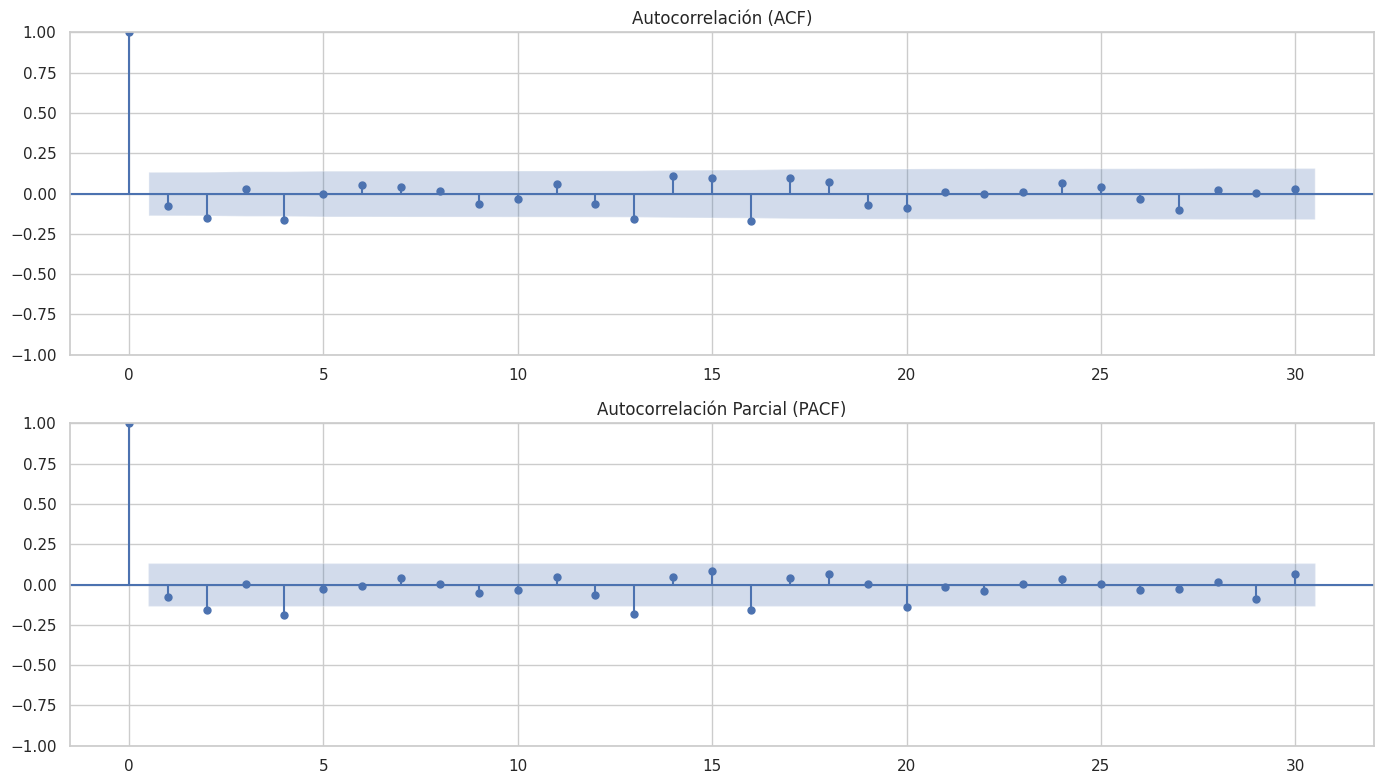

In [14]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(ts_data_diff, lags=30, ax=ax1, title="Autocorrelación (ACF)")
plot_pacf(ts_data_diff, lags=30, ax=ax2, title="Autocorrelación Parcial (PACF)")

plt.tight_layout()
plt.show()

Fase 3

In [15]:
df_features = ts_data[['views']].copy()
df_features['mes'] = df_features.index.month
df_features['dia_mes'] = df_features.index.day
df_features['dia_semana'] = df_features.index.dayofweek  # 0=Lunes, 6=Domingo
df_features['es_fin_semana'] = df_features['dia_semana'].isin([5, 6]).astype(int)

for lag in [1, 2, 3, 7]:
    df_features[f'views_lag_{lag}'] = df_features['views'].shift(lag)

df_features.head(10)

,views,mes,dia_mes,dia_semana,es_fin_semana,views_lag_1,views_lag_2,views_lag_3,views_lag_7
trending_date,,,,,,,,,
2017-11-14,185435246,11,14,1,0,NaN,NaN,NaN,NaN
2017-11-15,212445216,11,15,2,0,185435246.0,NaN,NaN,NaN
2017-11-16,227365391,11,16,3,0,212445216.0,185435246.0,NaN,NaN
2017-11-17,193541711,11,17,4,0,227365391.0,212445216.0,185435246.0,NaN
2017-11-18,196846875,11,18,5,1,193541711.0,227365391.0,212445216.0,NaN
2017-11-19,215052284,11,19,6,1,196846875.0,193541711.0,227365391.0,NaN
2017-11-20,257000111,11,20,0,0,215052284.0,196846875.0,193541711.0,NaN
2017-11-21,272366796,11,21,1,0,257000111.0,215052284.0,196846875.0,185435246.0
2017-11-22,283346688,11,22,2,0,272366796.0,257000111.0,215052284.0,212445216.0


In [16]:
df_features['views_roll_mean_3'] = df_features['views'].shift(1).rolling(window=3).mean()
df_features['views_roll_std_3'] = df_features['views'].shift(1).rolling(window=3).std()

df_features['views_roll_mean_7'] = df_features['views'].shift(1).rolling(window=7).mean()
df_features['views_roll_std_7'] = df_features['views'].shift(1).rolling(window=7).std()

df_features.dropna(inplace=True)

print(f"Tamaño del dataset final para modelar: {df_features.shape}")
df_features.head()

Tamaño del dataset final para modelar: (206, 13)


,views,mes,dia_mes,dia_semana,es_fin_semana,views_lag_1,views_lag_2,views_lag_3,views_lag_7,views_roll_mean_3,views_roll_std_3,views_roll_mean_7,views_roll_std_7
trending_date,,,,,,,,,,,,,
2017-11-21,272366796,11,21,1,0,257000111.0,215052284.0,196846875.0,185435246.0,2.229664e+08,3.084766e+07,2.125267e+08,2.430600e+07
2017-11-22,283346688,11,22,2,0,272366796.0,257000111.0,215052284.0,212445216.0,2.481397e+08,2.966678e+07,2.249455e+08,2.975454e+07
2017-11-23,279033536,11,23,3,0,283346688.0,272366796.0,257000111.0,227365391.0,2.709045e+08,1.323402e+07,2.350743e+08,3.616696e+07
2017-11-24,296317433,11,24,4,0,279033536.0,283346688.0,272366796.0,193541711.0,2.782490e+08,5.531828e+06,2.424554e+08,3.945444e+07
2017-11-25,312452069,11,25,5,1,296317433.0,279033536.0,283346688.0,196846875.0,2.862326e+08,8.996079e+06,2.571377e+08,3.728159e+07


In [17]:
df_us['like_dislike_ratio'] = df_us['likes'] / (df_us['dislikes'] + 1)
df_us['engagement_rate'] = (df_us['likes'] + df_us['comment_count']) / (df_us['views'] + 1)

df_us['log_views'] = np.log1p(df_us['views'])
df_us['log_likes'] = np.log1p(df_us['likes'])

In [18]:
fecha_corte = df_features.index.max() - pd.Timedelta(days=30)

train = df_features[df_features.index <= fecha_corte]
test = df_features[df_features.index > fecha_corte]

X_train = train.drop(columns=['views'])
y_train = train['views']

X_test = test.drop(columns=['views'])
y_test = test['views']

print(f"Registros de Entrenamiento (Pasado): {X_train.shape[0]} días (Hasta {train.index.max().strftime('%Y-%m-%d')})")
print(f"Registros de Prueba (Futuro): {X_test.shape[0]} días (Desde {test.index.min().strftime('%Y-%m-%d')})")

Registros de Entrenamiento (Pasado): 176 días (Hasta 2018-05-15)
Registros de Prueba (Futuro): 30 días (Desde 2018-05-16)


Fase 4: Modelado y predicción

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluar_modelo(y_real, y_pred, nombre_modelo):
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mape = np.mean(np.abs((y_real - y_pred) / y_real)) * 100

    print(f"Métricas de {nombre_modelo}")
    print(f"MAE : {mae:,.2f} vistas")
    print(f"RMSE: {rmse:,.2f} vistas")
    print(f"MAPE: {mape:.2f}%\n")

    return {"MAE": mae, "RMSE": rmse, "MAPE": mape}
resultados = {}

In [21]:
y_pred_baseline = X_test['views_lag_1']
resultados['Baseline'] = evaluar_modelo(y_test, y_pred_baseline, "Línea Base (Ayer = Hoy)")

Métricas de Línea Base (Ayer = Hoy)
MAE : 61,121,915.53 vistas
RMSE: 75,421,553.61 vistas
MAPE: 6.07%



In [22]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
modelo_hw = ExponentialSmoothing(y_train, trend='add', seasonal='add', seasonal_periods=7).fit()

y_pred_hw = modelo_hw.forecast(steps=len(y_test))

resultados['Holt-Winters'] = evaluar_modelo(y_test, y_pred_hw, "Holt-Winters (Estadístico)")

Métricas de Holt-Winters (Estadístico)
MAE : 98,687,766.04 vistas
RMSE: 113,049,718.59 vistas
MAPE: 9.66%



In [23]:
from sklearn.ensemble import RandomForestRegressor

modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)

y_pred_rf = pd.Series(y_pred_rf, index=y_test.index)

resultados['Random Forest'] = evaluar_modelo(y_test, y_pred_rf, "Random Forest (Machine Learning)")

Métricas de Random Forest (Machine Learning)
MAE : 135,473,230.40 vistas
RMSE: 162,305,738.64 vistas
MAPE: 12.69%



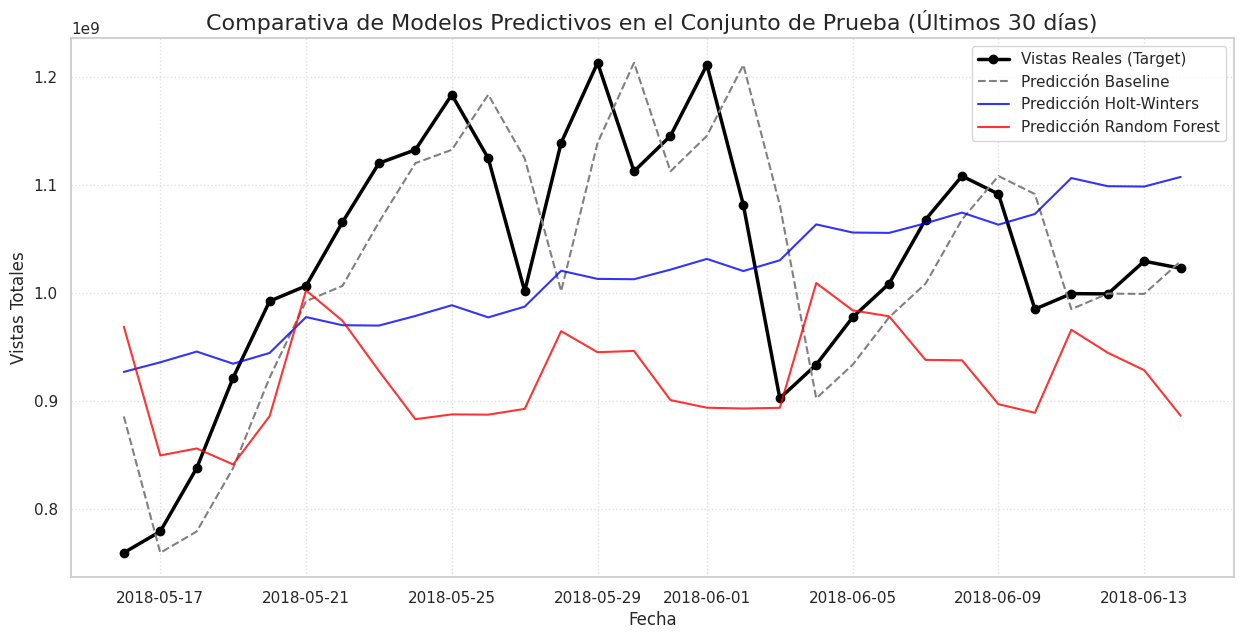

In [24]:
plt.figure(figsize=(15, 7))
plt.plot(y_test.index, y_test, label='Vistas Reales (Target)', color='black', linewidth=2.5, marker='o')
plt.plot(y_test.index, y_pred_baseline, label='Predicción Baseline', color='gray', linestyle='--')
plt.plot(y_test.index, y_pred_hw, label='Predicción Holt-Winters', color='blue', alpha=0.8)
plt.plot(y_test.index, y_pred_rf, label='Predicción Random Forest', color='red', alpha=0.8)

plt.title('Comparativa de Modelos Predictivos en el Conjunto de Prueba (Últimos 30 días)', fontsize=16)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Vistas Totales', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

Detección de anomalías

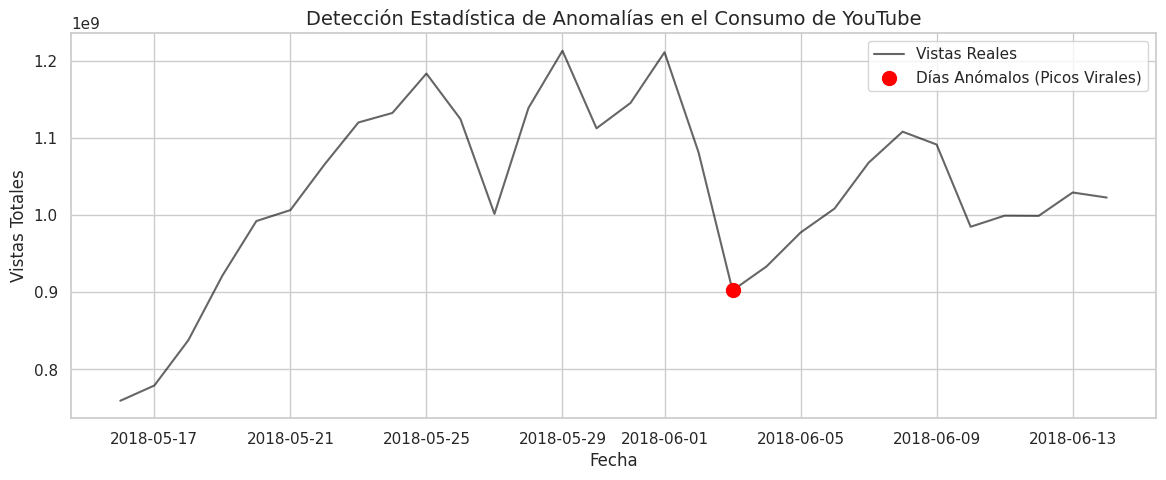

Se detectaron 1 días anómalos en el conjunto de prueba.


In [25]:
df_anomalias = pd.DataFrame(index=y_test.index)
df_anomalias['Real'] = y_test
df_anomalias['Prediccion'] = y_pred_baseline
df_anomalias['Error_Absoluto'] = (df_anomalias['Real'] - df_anomalias['Prediccion']).abs()

media_error = df_anomalias['Error_Absoluto'].mean()
std_error = df_anomalias['Error_Absoluto'].std()
umbral = media_error + (2.5 * std_error)

df_anomalias['Es_Anomalia'] = df_anomalias['Error_Absoluto'] > umbral

plt.figure(figsize=(14, 5))
plt.plot(df_anomalias.index, df_anomalias['Real'], label='Vistas Reales', color='black', alpha=0.6)
anomalias = df_anomalias[df_anomalias['Es_Anomalia']]
plt.scatter(anomalias.index, anomalias['Real'], color='red', s=100, zorder=5, label='Días Anómalos (Picos Virales)')

plt.title('Detección Estadística de Anomalías en el Consumo de YouTube', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Vistas Totales')
plt.legend()
plt.show()

print(f"Se detectaron {df_anomalias['Es_Anomalia'].sum()} días anómalos en el conjunto de prueba.")

Predicción de ciclo de vida de un video

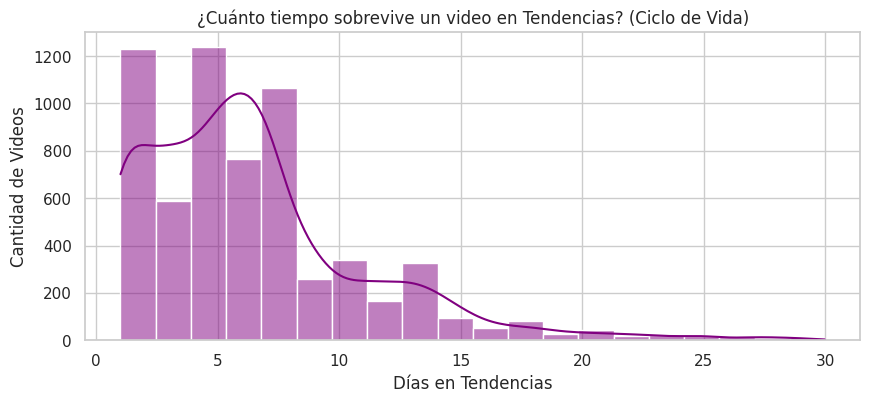

Promedio de permanencia: 6.45 días.


In [26]:
vida_util = df_us.groupby('video_id').agg(
    dias_en_tendencias=('trending_date', 'count'),
    vistas_primer_dia=('views', 'first'),
    likes_primer_dia=('likes', 'first'),
    dislikes_primer_dia=('dislikes', 'first'),
    comentarios_primer_dia=('comment_count', 'first'),
    categoria=('category_name', 'first')
).reset_index()

vida_util = vida_util[vida_util['vistas_primer_dia'] > 0]

plt.figure(figsize=(10, 4))
sns.histplot(vida_util['dias_en_tendencias'], bins=20, kde=True, color='purple')
plt.title('¿Cuánto tiempo sobrevive un video en Tendencias? (Ciclo de Vida)')
plt.xlabel('Días en Tendencias')
plt.ylabel('Cantidad de Videos')
plt.show()

print(f"Promedio de permanencia: {vida_util['dias_en_tendencias'].mean():.2f} días.")

In [28]:
from sklearn.linear_model import LinearRegression

X_vida = vida_util[['vistas_primer_dia', 'likes_primer_dia', 'comentarios_primer_dia']]
y_vida = vida_util['dias_en_tendencias']

modelo_vida = LinearRegression()
modelo_vida.fit(X_vida, y_vida)

print("Coeficientes de Impacto en el Ciclo de Vida")
for col, coef in zip(X_vida.columns, modelo_vida.coef_):
    print(f"{col}: {coef:.8f}")

Coeficientes de Impacto en el Ciclo de Vida
vistas_primer_dia: 0.00000029
likes_primer_dia: 0.00000625
comentarios_primer_dia: -0.00002113


Comparativa internacional

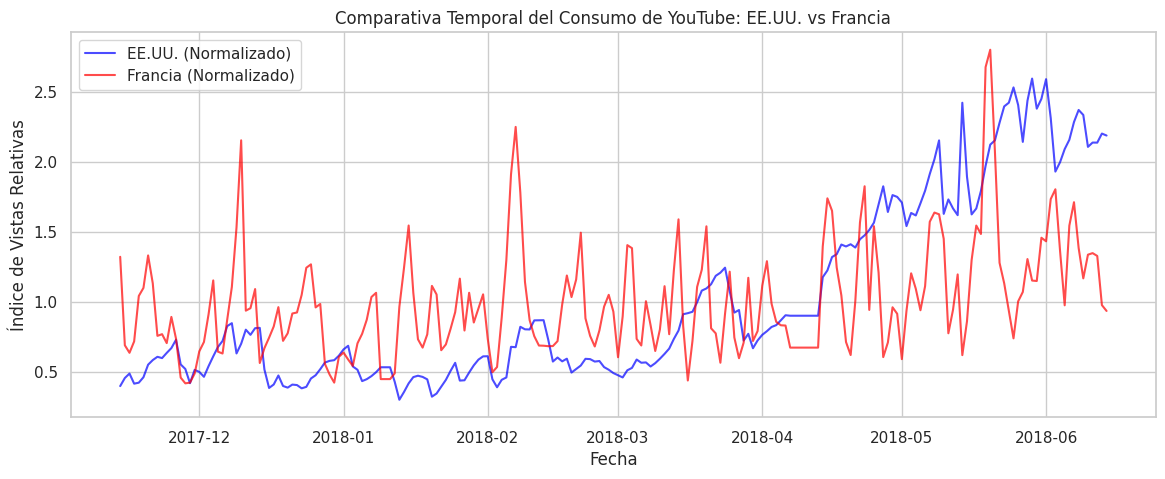

In [29]:
df_fr = pd.read_csv('youtube_data/FRvideos.csv')
df_fr['trending_date'] = pd.to_datetime(df_fr['trending_date'], format='%y.%d.%m')

ts_fr = df_fr.groupby('trending_date')['views'].sum().asfreq('D', method='ffill')

vistas_us_norm = ts_data['views'] / ts_data['views'].mean()
vistas_fr_norm = ts_fr / ts_fr.mean()

plt.figure(figsize=(14, 5))
plt.plot(vistas_us_norm.index, vistas_us_norm, label='EE.UU. (Normalizado)', color='blue', alpha=0.7)
plt.plot(vistas_fr_norm.index, vistas_fr_norm, label='Francia (Normalizado)', color='red', alpha=0.7)
plt.title('Comparativa Temporal del Consumo de YouTube: EE.UU. vs Francia')
plt.xlabel('Fecha')
plt.ylabel('Índice de Vistas Relativas')
plt.legend()
plt.show()

Análisis global Multi-País

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

paises = {
    'US': 'Estados Unidos',
    'CA': 'Canadá',
    'GB': 'Reino Unido',
    'FR': 'Francia',
    'DE': 'Alemania',
    'IN': 'India',
    'JP': 'Japón',
    'KR': 'Corea del Sur',
    'MX': 'México',
    'RU': 'Rusia'
}

df_global = pd.DataFrame()

for codigo, nombre in paises.items():
    ruta = f'youtube_data/{codigo}videos.csv'

    try:
        df_temp = pd.read_csv(ruta, lineterminator='\n', encoding='latin1')
        df_temp['trending_date'] = pd.to_datetime(df_temp['trending_date'], format='%y.%d.%m', errors='coerce')

        ts_pais = df_temp.groupby('trending_date')['views'].sum()

        df_global[nombre] = ts_pais
    except FileNotFoundError:
        print(f"Archivo para {nombre} ({codigo}) no encontrado. Saltando...")

df_global = df_global.asfreq('D', method='ffill').dropna()

print(f"Matriz global consolidada. Dimensiones: {df_global.shape} (Días x Países)")
df_global.head()

Matriz global consolidada. Dimensiones: (128, 10) (Días x Países)


,Estados Unidos,Canadá,Reino Unido,Francia,Alemania,India,Japón,Corea del Sur,México,Rusia
trending_date,,,,,,,,,,
2018-02-07,315519845,270180100,1005426400,184695313,208412022,266790933,92215312.0,94963044,117449737,58306793
2018-02-08,383653654,340375500,1030451385,146133242,226127733,268852015,93214852.0,112990511,34456825,59169582
2018-02-09,375218909,378186660,1095358055,93665211,247615688,212092946,33526797.0,95040366,55368466,55236533
2018-02-10,374687228,330108435,877116984,71279795,129616008,208317219,29961594.0,103727530,50785841,35876797
2018-02-11,405072163,223241093,952506648,61851056,111605612,201493992,30635747.0,33569074,65405956,33224067


In [31]:
df_global_norm = df_global.div(df_global.mean())

df_global_norm.head()

,Estados Unidos,Canadá,Reino Unido,Francia,Alemania,India,Japón,Corea del Sur,México,Rusia
trending_date,,,,,,,,,,
2018-02-07,0.511885,1.170969,0.629575,2.062050,1.610331,1.220778,2.144045,1.359757,1.753628,1.118111
2018-02-08,0.622422,1.475199,0.645245,1.631519,1.747214,1.230209,2.167284,1.617888,0.514471,1.134656
2018-02-09,0.608738,1.639073,0.685888,1.045735,1.913244,0.970492,0.779512,1.360864,0.826700,1.059235
2018-02-10,0.607875,1.430701,0.549230,0.795811,1.001500,0.953215,0.696620,1.485253,0.758277,0.687986
2018-02-11,0.657171,0.967534,0.596438,0.690542,0.862340,0.921993,0.712294,0.480669,0.976568,0.637116


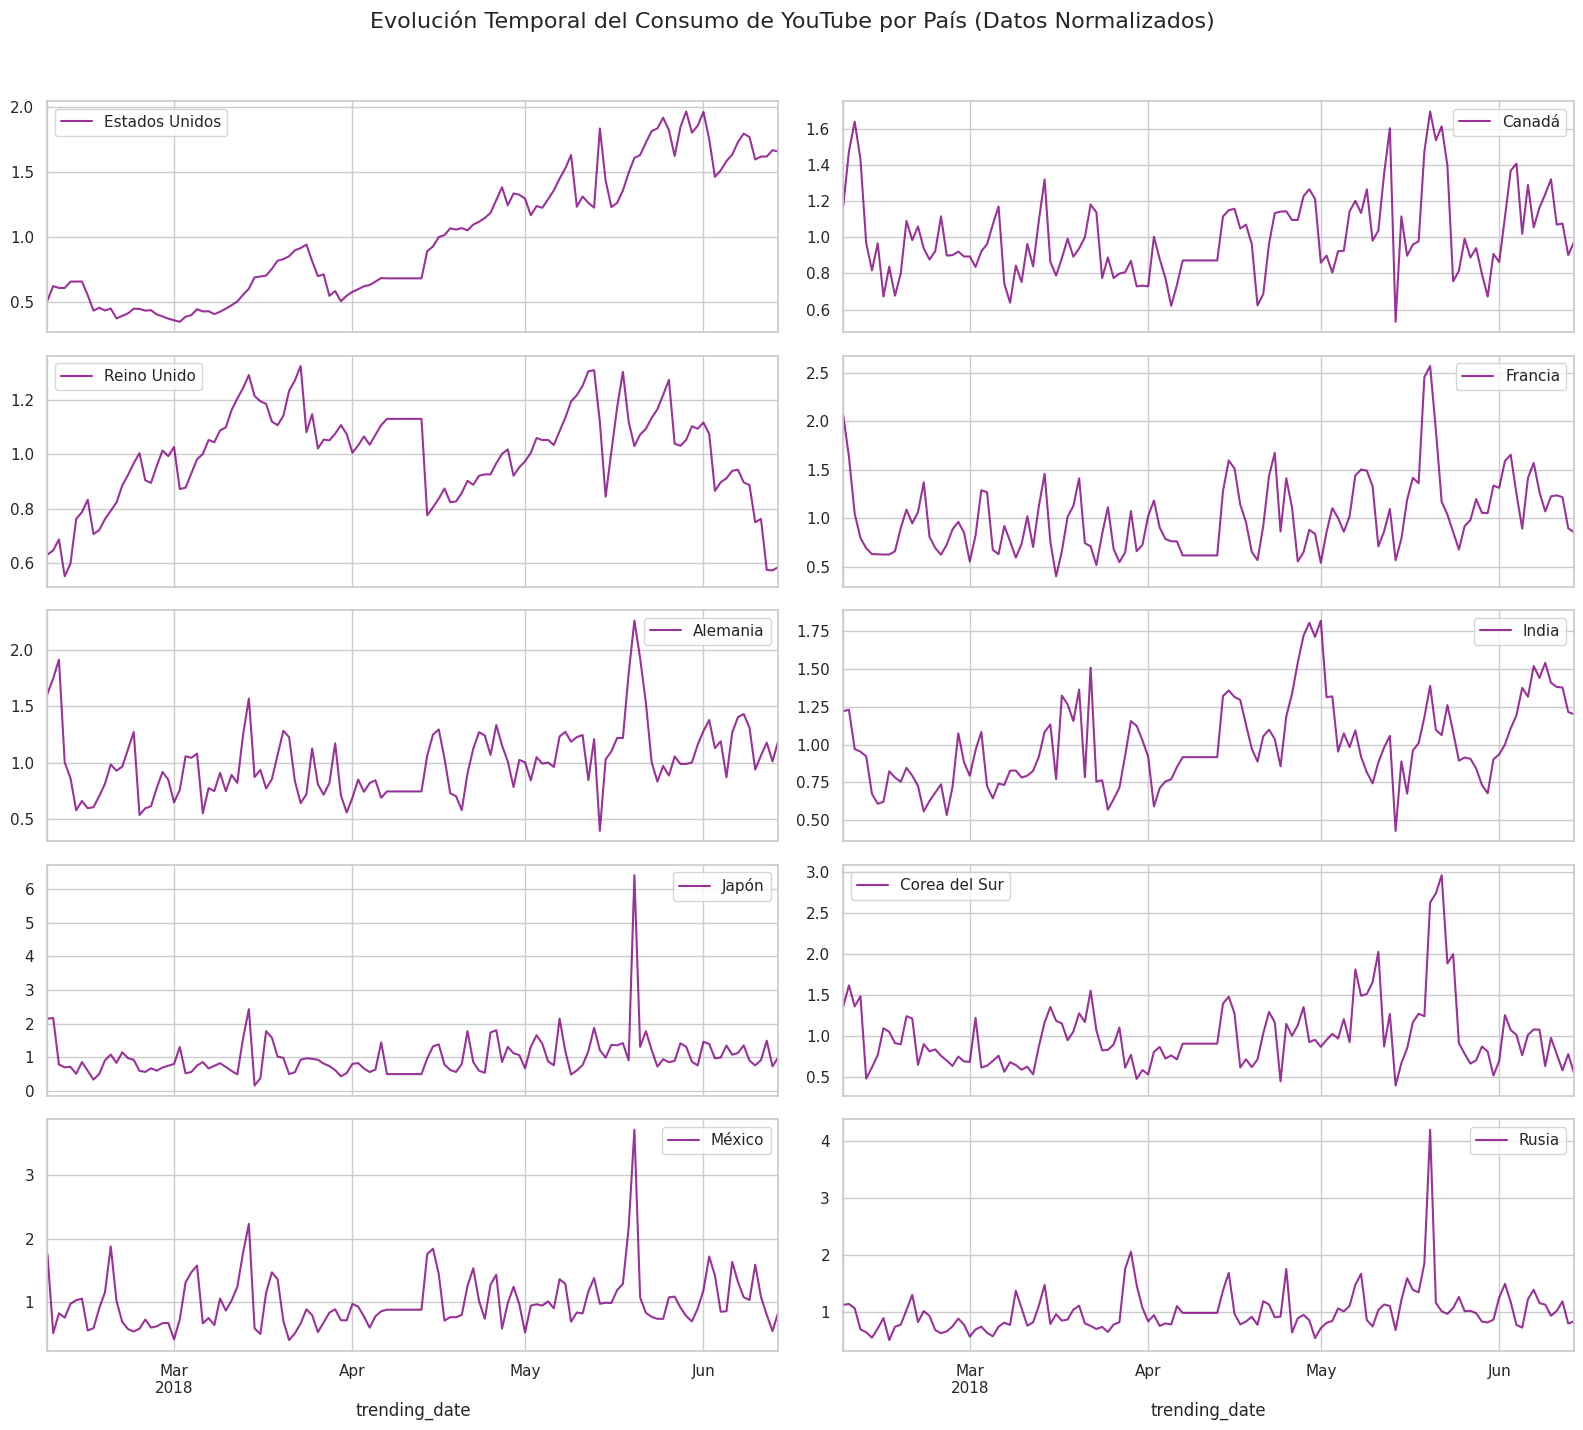

In [32]:
df_global_norm.plot(subplots=True, layout=(5, 2), figsize=(16, 14), sharex=True, color='purple', alpha=0.8)

plt.suptitle('Evolución Temporal del Consumo de YouTube por País (Datos Normalizados)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

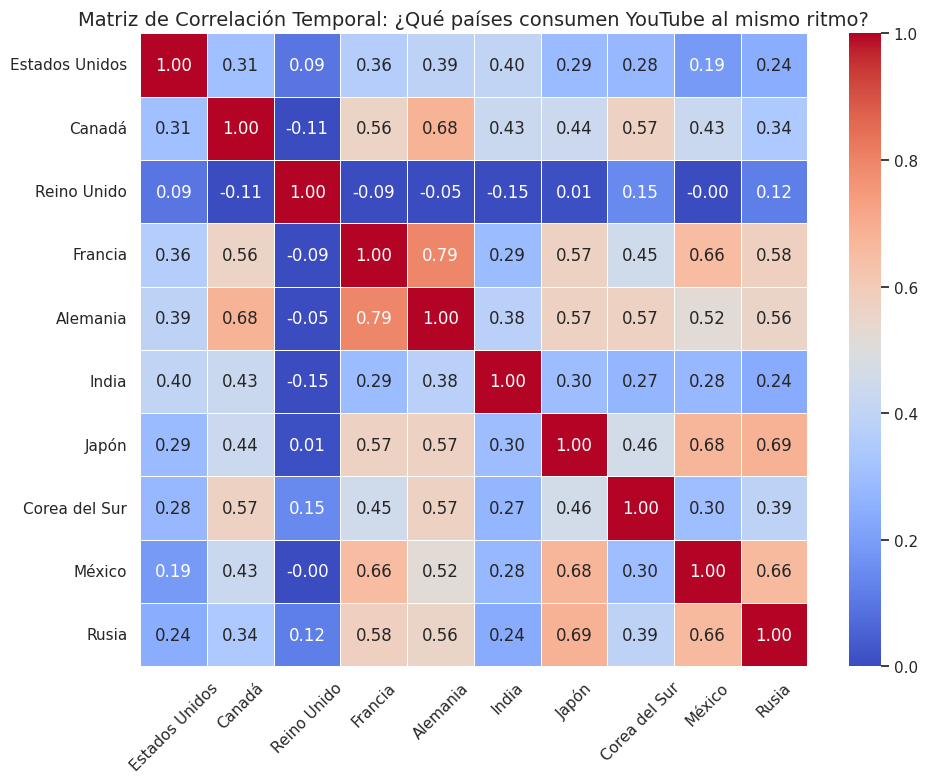

In [33]:
plt.figure(figsize=(10, 8))

matriz_corr = df_global_norm.corr()

sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', vmin=0, vmax=1, fmt=".2f", linewidths=0.5)

plt.title('Matriz de Correlación Temporal: ¿Qué países consumen YouTube al mismo ritmo?', fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Curvas de aprendizaje

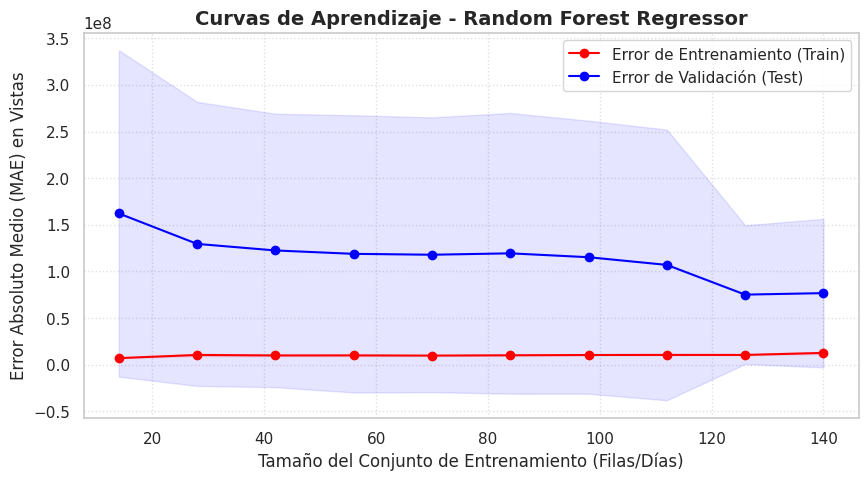

In [34]:
from sklearn.model_selection import learning_curve

def graficar_curva_aprendizaje(modelo, X, y, nombre_modelo):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator=modelo,
        X=X,
        y=y,
        train_sizes=np.linspace(0.1, 1.0, 10),
        cv=5,
        scoring='neg_mean_absolute_error',
        n_jobs=-1,
        random_state=42
    )

    train_errors = -train_scores.mean(axis=1)
    test_errors = -test_scores.mean(axis=1)

    train_std = train_scores.std(axis=1)
    test_std = test_scores.std(axis=1)

    plt.figure(figsize=(10, 5))

    plt.plot(train_sizes, train_errors, 'o-', color="red", label="Error de Entrenamiento (Train)")
    plt.fill_between(train_sizes, train_errors - train_std, train_errors + train_std, alpha=0.1, color="red")

    plt.plot(train_sizes, test_errors, 'o-', color="blue", label="Error de Validación (Test)")
    plt.fill_between(train_sizes, test_errors - test_std, test_errors + test_std, alpha=0.1, color="blue")

    plt.title(f'Curvas de Aprendizaje - {nombre_modelo}', fontsize=14, fontweight='bold')
    plt.xlabel('Tamaño del Conjunto de Entrenamiento (Filas/Días)')
    plt.ylabel('Error Absoluto Medio (MAE) en Vistas')
    plt.legend(loc="best", fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

graficar_curva_aprendizaje(modelo_rf, X_train, y_train, "Random Forest Regressor")

Predicción

In [40]:
import pandas as pd
import numpy as np

df_us['trending_date'] = pd.to_datetime(df_us['trending_date'], format='%y.%d.%m')
df_us['publish_time'] = pd.to_datetime(df_us['publish_time'], format='%Y-%m-%dT%H:%M:%S.%fZ', errors='coerce')
df_us['publish_date'] = pd.to_datetime(df_us['publish_time'].dt.date)

df_videos = df_us.groupby('video_id').agg(
    title=('title', 'first'),
    category_id=('category_id', 'first'),
    publish_time=('publish_time', 'first'),
    publish_date=('publish_date', 'first'),
    max_views=('views', 'max'),
    total_trending_days=('trending_date', 'count')
).reset_index()

df_videos['publish_hour'] = df_videos['publish_time'].dt.hour
df_videos['publish_day_of_week'] = df_videos['publish_time'].dt.dayofweek
df_videos['publish_is_weekend'] = df_videos['publish_day_of_week'].isin([5, 6]).astype(int)

df_videos['title_length'] = df_videos['title'].apply(lambda x: len(str(x)))
df_videos['title_uppercase_count'] = df_videos['title'].apply(lambda x: sum(1 for c in str(x) if c.isupper()))

df_pipeline = pd.get_dummies(df_videos, columns=['category_id'], drop_first=True)


In [42]:
from sklearn.model_selection import train_test_split

df_pipeline = df_pipeline.sort_values('publish_time')

feature_cols = ['publish_hour', 'publish_day_of_week', 'publish_is_weekend', 'title_length', 'title_uppercase_count'] + \
               [col for col in df_pipeline.columns if 'category_id_' in col]

X = df_pipeline[feature_cols]
y = df_pipeline['max_views']

split_index = int(len(df_pipeline) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"Registros de Entrenamiento (Pasado): {X_train.shape[0]}")
print(f"Registros de Prueba (Futuro): {X_test.shape[0]}")

Registros de Entrenamiento (Pasado): 5080
Registros de Prueba (Futuro): 1271



Métricas de evaluación
Error Absoluto Medio (MAE): 3,641,619 visitas
Raíz del Error Cuadrático Medio (RMSE): 12,097,887 visitas
Coeficiente de Determinación (R²): 0.0401


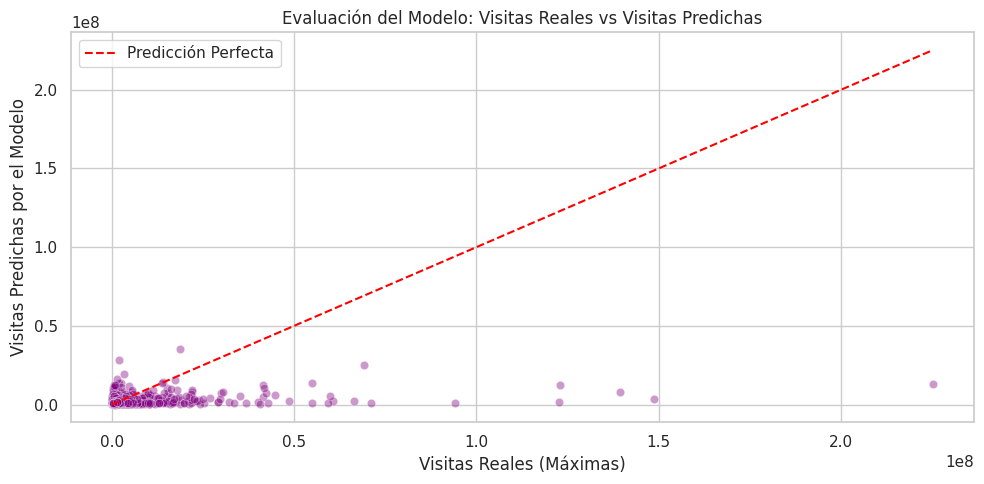

In [43]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

model_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_rf.fit(X_train, y_train)

y_pred = model_rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nMétricas de evaluación")
print(f"Error Absoluto Medio (MAE): {mae:,.0f} visitas")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:,.0f} visitas")
print(f"Coeficiente de Determinación (R²): {r2:.4f}")

plt.figure(figsize=(10, 5))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.4, color='purple')

perfect_line = np.linspace(min(y_test), max(y_test), 100)
plt.plot(perfect_line, perfect_line, color='red', linestyle='--', label='Predicción Perfecta')
plt.title("Evaluación del Modelo: Visitas Reales vs Visitas Predichas")
plt.xlabel("Visitas Reales (Máximas)")
plt.ylabel("Visitas Predichas por el Modelo")
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_3713/1758758580.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices][:10], y=[feature_cols[i] for i in indices][:10], palette="viridis")


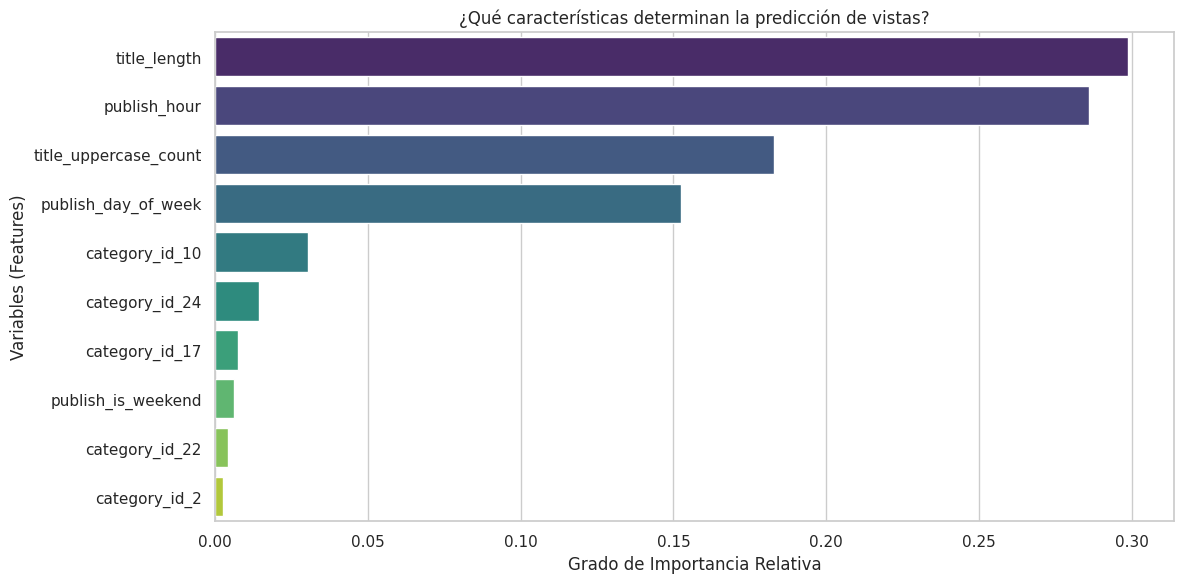

In [44]:
importances = model_rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("¿Qué características determinan la predicción de vistas?")
sns.barplot(x=importances[indices][:10], y=[feature_cols[i] for i in indices][:10], palette="viridis")
plt.xlabel("Grado de Importancia Relativa")
plt.ylabel("Variables (Features)")
plt.tight_layout()
plt.show()

Tiempo de vida en tendencia predicción

In [47]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

df_first_day = df_us.sort_values('trending_date').groupby('video_id').first().reset_index()

df_longevity = df_us.groupby('video_id').agg(
    total_trending_days=('trending_date', 'count'),
    publish_time=('publish_time', 'first')
).reset_index()

df_pipeline_2 = pd.merge(df_first_day, df_longevity, on='video_id', suffixes=('_day1', '_total'))

df_pipeline_2['like_ratio'] = df_pipeline_2['likes'] / (df_pipeline_2['views'] + 1)
df_pipeline_2['comment_ratio'] = df_pipeline_2['comment_count'] / (df_pipeline_2['views'] + 1)
df_pipeline_2['dislike_ratio'] = df_pipeline_2['dislikes'] / (df_pipeline_2['likes'] + df_pipeline_2['dislikes'] + 1)

df_pipeline_2['publish_time_day1'] = pd.to_datetime(df_pipeline_2['publish_time_day1'], errors='coerce')
df_pipeline_2['publish_hour'] = df_pipeline_2['publish_time_day1'].dt.hour
df_pipeline_2['publish_day_of_week'] = df_pipeline_2['publish_time_day1'].dt.dayofweek

df_pipeline_2 = pd.get_dummies(df_pipeline_2, columns=['category_id'], drop_first=True)

features_longevity = [
    'views', 'like_ratio', 'comment_ratio', 'dislike_ratio',
    'publish_hour', 'publish_day_of_week'
] + [col for col in df_pipeline_2.columns if 'category_id_' in col]

df_pipeline_2 = df_pipeline_2.replace([np.inf, -np.inf], np.nan).dropna(subset=features_longevity + ['total_trending_days'])

X2 = df_pipeline_2[features_longevity]
y2 = df_pipeline_2['total_trending_days']

df_pipeline_2 = df_pipeline_2.sort_values('publish_time_day1')
split_idx = int(len(df_pipeline_2) * 0.8)

X_train2, X_test2 = X2.iloc[:split_idx], X2.iloc[split_idx:]
y_train2, y_test2 = y2.iloc[:split_idx], y2.iloc[split_idx:]



Métricas de longevidad
Error Absoluto Medio (MAE): 3.37 días
Coeficiente de Determinación (R²): 0.1614


/tmp/ipykernel_3713/22722374.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances2[indices2][:8], y=[features_longevity[i] for i in indices2][:8], palette="mako")


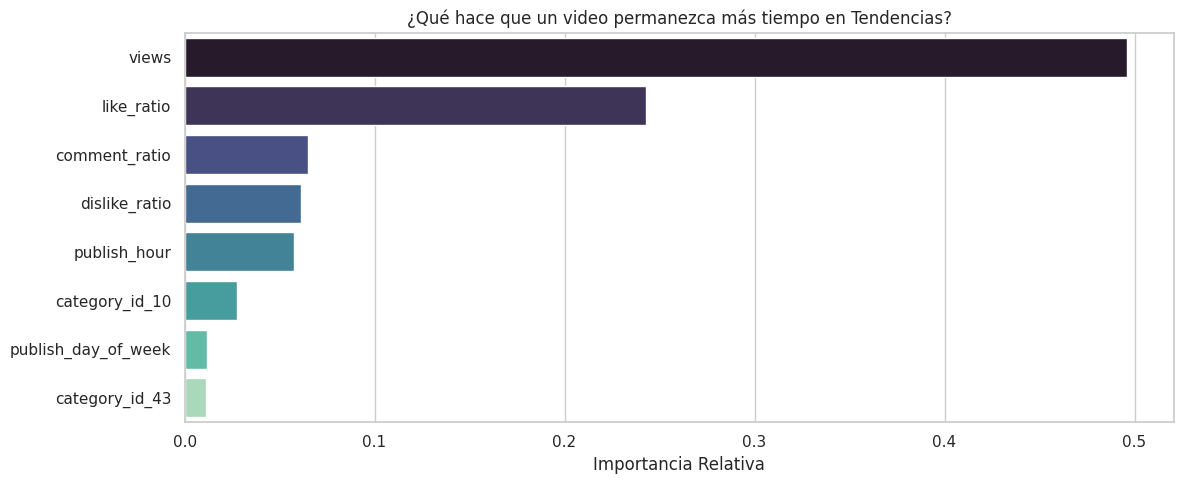

In [48]:
model_gb = GradientBoostingRegressor(n_estimators=150, learning_rate=0.05, random_state=42)
model_gb.fit(X_train2, y_train2)

y_pred2 = model_gb.predict(X_test2)

mae2 = mean_absolute_error(y_test2, y_pred2)
r2_2 = r2_score(y_test2, y_pred2)

print("\nMétricas de longevidad")
print(f"Error Absoluto Medio (MAE): {mae2:.2f} días")
print(f"Coeficiente de Determinación (R²): {r2_2:.4f}")

importances2 = model_gb.feature_importances_
indices2 = np.argsort(importances2)[::-1]

plt.figure(figsize=(12, 5))
plt.title("¿Qué hace que un video permanezca más tiempo en Tendencias?")
sns.barplot(x=importances2[indices2][:8], y=[features_longevity[i] for i in indices2][:8], palette="mako")
plt.xlabel("Importancia Relativa")
plt.tight_layout()
plt.show()